In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

Import numpy digunakan untuk hitung-hitungan angka. Gambar itu adalah kumpulan angka (matriks). Import matplotlib digunakan untuk tampilan gambar dan juga membuat grafik histogram. Import pandas digunakan untuk merapikan data statistik ke dalam tabel. Import opencv digunakan untuk membaca, mengubah warna dan memanipulasi gambar.

Kode di bawah ini berfungsi untuk membaca citra yang disimpan di variabel backup menggunakan OpenCV, mengubahnya ke dalam format grayscale dengan cv2.cvtColor, lalu plt.axis('off') untuk tidak menampilkan sumbu-x dan sumbu-y.

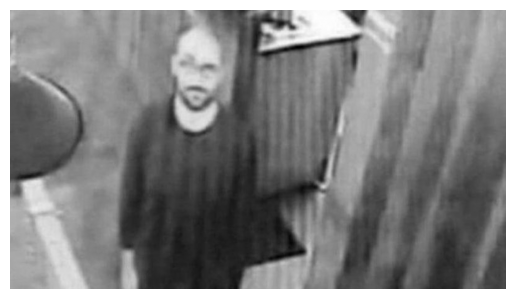

In [8]:
backup = cv2.imread('backup.jpg')
backup_gray = cv2.cvtColor(backup, cv2.COLOR_BGR2GRAY)
plt.imshow(backup_gray, cmap='gray')
plt.axis('off')
plt.show()

Kode di bawah ini mengimplementasikan fungsi filtering yang menerapkan tiga jenis filter yaitu mean, median, dan modus pada citra grayscale dengan ukuran kernel variabel (3x3 dan 9x9) melalui mekanisme padding tepi, di mana hasil keluaran kemudian divisualisasikan dalam tata letak subplot 3x2 menggunakan Matplotlib.

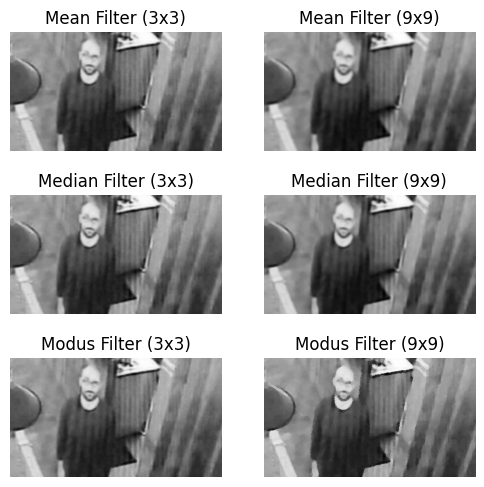

In [15]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.mean(region).astype(np.uint8)
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.median(region).astype(np.uint8)
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

mean3 = filter(backup_gray, 3, 'mean')
mean9 = filter(backup_gray, 9, 'mean')

median3 = filter(backup_gray, 3, 'median')
median9 = filter(backup_gray, 9, 'median')

modus3 = filter(backup_gray, 3, 'modus')
modus9 = filter(backup_gray, 9, 'modus')

plt.figure(figsize=(6, 6))

plt.subplot(3,2,1)
plt.title("Mean Filter (3x3)")
plt.imshow(mean3, cmap='gray')
plt.axis('off')

plt.subplot(3,2,2)
plt.title("Mean Filter (9x9)")
plt.imshow(mean9, cmap='gray')
plt.axis('off')

plt.subplot(3,2,3)
plt.title("Median Filter (3x3)")
plt.imshow(median3, cmap='gray')
plt.axis('off')

plt.subplot(3,2,4)
plt.title("Median Filter (9x9)")
plt.imshow(median9, cmap='gray')
plt.axis('off')

plt.subplot(3,2,5)
plt.title("Modus Filter (3x3)")
plt.imshow(modus3, cmap='gray')
plt.axis('off')

plt.subplot(3,2,6)
plt.title("Modus Filter (9x9)")
plt.imshow(modus9, cmap='gray')
plt.axis('off')

plt.show()

Kode di bawah ini adalah operasi konvolusi citra menggunakan fungsi convolution yang menerapkan dua kernel 3x3 berbeda, yaitu kernel smoothing (perataan) dan sharpening (penajaman), pada citra grayscale (backup_gray) melalui proses zero-padding dan perhitungan jumlah elemen hasil perkalian region dengan kernel, kemudian memvisualisasikan hasil masing-masing filter serta gabungan keduanya (smooth + sharp) dalam tiga subplot.

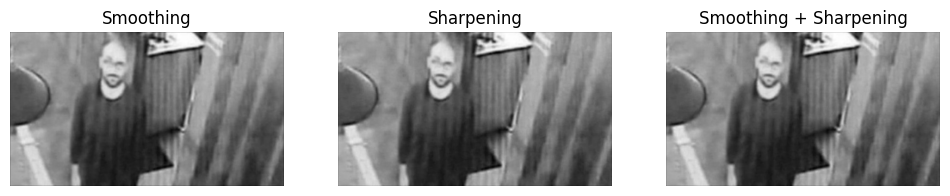

In [38]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
 ])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

smooth = convolution (backup_gray, kernelSmoothing)
sharp = convolution (backup_gray, kernelSharpening)
sm_plus_sh = smooth + sharp

plt.figure(figsize=(12,12))

plt.subplot(1,3,1)
plt.title("Smoothing")
plt.imshow(smooth, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sharpening")
plt.imshow(sharp, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Smoothing + Sharpening")
plt.imshow(sm_plus_sh, cmap='gray')
plt.axis('off')

plt.show()

Apakah Perbedaan Antara ke-3 metode tersebut? Jelaskan kegunaan dan perbedaanya!
Jawaban: 
Metode Smoothing digunakan untuk menghaluskan citra dengan cara mengurangi noise atau detail-detail kecil sehingga gambar terlihat lebih lembut dan rata. Metode Sharpening digunakan untuk mempertajam citra dengan menonjolkan tepi dan detail objek agar gambar terlihat lebih jelas dan tajam. Sedangkan metode Smoothing + Sharpening merupakan gabungan keduanya, yaitu citra terlebih dahulu dihaluskan untuk mengurangi noise lalu dipertajam kembali agar detail penting tetap terlihat jelas. Perbedaannya terletak pada tujuan pengolahan citra, di mana smoothing fokus pada pengurangan noise, sharpening fokus pada penegasan detail, dan kombinasi keduanya bertujuan menghasilkan citra yang lebih bersih namun tetap tajam.

Apa Perbedaan Hasil dari Mean, Median dan Modus?
Jawaban:
Hasil dari Mean Filter cenderung membuat citra menjadi lebih halus karena nilai piksel diganti dengan rata-rata piksel di sekitarnya, namun detail dan tepi gambar bisa menjadi kabur. Median Filter menghasilkan citra yang lebih bersih dari noise terutama noise salt and pepper, karena nilai piksel diganti dengan nilai tengah dari piksel di sekitarnya sehingga tepi objek lebih terjaga dibanding mean filter. Sedangkan Modus Filter mengganti nilai piksel dengan nilai yang paling sering muncul di area sekitar sehingga dapat mempertahankan pola atau warna dominan pada citra. Perbedaannya terletak pada cara menentukan nilai pengganti piksel, yaitu mean menggunakan rata-rata, median menggunakan nilai tengah, dan modus menggunakan nilai yang paling sering muncul.
 

In [50]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)


robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

prewitt = edge(sm_plus_sh, prewittX, prewittY)
sobel = edge(sm_plus_sh, sobelX, sobelY)
robert = edge(sm_plus_sh, robertsX, robertsY)
ps  = prewitt.astype(np.float32) + sobel.astype(np.float32)
pr  = prewitt.astype(np.float32) + robert.astype(np.float32)
sr  = sobel.astype(np.float32) + robert.astype(np.float32)
psr = prewitt.astype(np.float32) + sobel.astype(np.float32) + robert.astype(np.float32)

Kode di atas ini digunakan untuk melakukan deteksi tepi (edge detection) pada citra menggunakan metode Sobel, Prewitt, dan Roberts. Fungsi edge() bekerja dengan melakukan konvolusi citra terhadap kernel horizontal (kernelx) dan vertikal (kernely) untuk mendapatkan perubahan intensitas piksel pada dua arah, kemudian hasilnya digabung menggunakan nilai absolut agar tepi objek terlihat lebih jelas. Kernel Sobel digunakan untuk mendeteksi tepi dengan hasil yang lebih halus dan detail, Prewitt digunakan untuk mendeteksi tepi dengan perhitungan yang lebih sederhana, sedangkan Roberts digunakan untuk mendeteksi perubahan intensitas secara cepat pada diagonal citra. Setelah itu, hasil dari masing-masing metode digabungkan (ps, pr, sr, dan psr).

Kode di bawah ini digunakan untuk melakukan normalisasi citra hasil deteksi tepi agar nilai piksel berada pada rentang 0–255 sehingga gambar dapat ditampilkan dengan lebih jelas. Fungsi normalisasi() mencari nilai piksel minimum dan maksimum pada citra, lalu setiap piksel diubah menggunakan rumus skala linear sehingga kontras citra menjadi lebih baik. Setelah itu, hasil deteksi tepi dari metode Prewitt, Sobel, Roberts, serta kombinasi ketiganya dinormalisasi dan ditampilkan menggunakan matplotlib untuk membandingkan hasil masing-masing metode deteksi tepi.

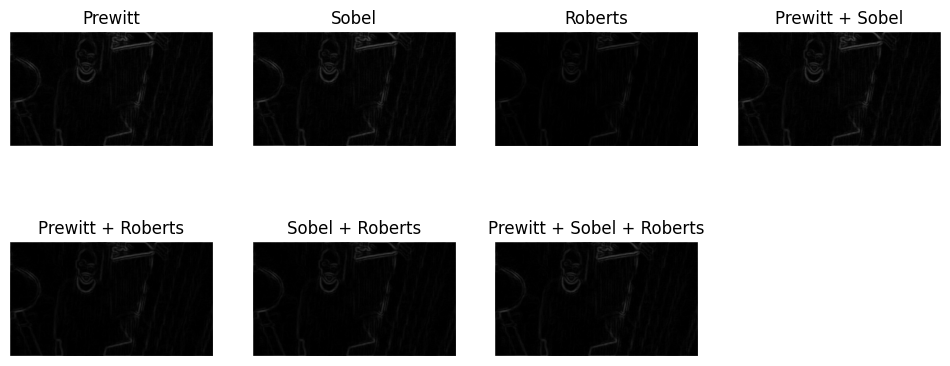

In [51]:
def normalisasi(image):
    h, w = image.shape
    
    min_pixel = image[0, 0]
    max_pixel = image[0, 0]
    for i in range(h):
        for j in range(w):
            if image[i, j] < min_pixel:
                min_pixel = image[i, j]
            if image[i, j] > max_pixel:
                max_pixel = image[i, j]
    
    if max_pixel == min_pixel:
        return image
    
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            baru = (image[i, j] - min_pixel) / (max_pixel - min_pixel) * 255
            hasil[i, j] = int(baru)
    
    return hasil

prewitt_normal = normalisasi(prewitt)
sobel_normal = normalisasi(sobel)
robert_normal = normalisasi(robert)
ps_normal = normalisasi(ps)
pr_normal = normalisasi(pr)
sr_normal = normalisasi(sr)
psr_normal = normalisasi(psr)

plt.figure(figsize=(12,5))

plt.subplot(2,4,1)
plt.title("Prewitt")
plt.imshow(prewitt_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,2)
plt.title("Sobel")
plt.imshow(sobel_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,3)
plt.title("Roberts")
plt.imshow(robert_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,4)
plt.title("Prewitt + Sobel")
plt.imshow(ps_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,5)
plt.title("Prewitt + Roberts")
plt.imshow(pr_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,6)
plt.title("Sobel + Roberts")
plt.imshow(sr_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,4,7)
plt.title("Prewitt + Sobel + Roberts")
plt.imshow(psr_normal, cmap='gray')
plt.axis('off')

plt.show()

Jelaskan kegunaan operator dan kombinasi dari operator-operator tersebut! 
Jawaban:
Operator deteksi tepi seperti Prewitt, Sobel, dan Roberts digunakan untuk mendeteksi perubahan intensitas piksel pada citra sehingga tepi objek dapat terlihat lebih jelas. Operator Prewitt berguna untuk mendeteksi tepi dengan perhitungan sederhana, Sobel lebih baik dalam menonjolkan detail dan mengurangi noise karena memiliki bobot lebih besar di bagian tengah kernel, sedangkan Roberts digunakan untuk mendeteksi perubahan intensitas secara cepat terutama pada arah diagonal. Kombinasi operator-operator tersebut bertujuan untuk menghasilkan deteksi tepi yang lebih lengkap dan akurat, karena setiap operator memiliki karakteristik berbeda dalam menangkap detail dan arah tepi pada citra.

Kode di bawah ini digunakan untuk melakukan proses thresholding pada citra hasil deteksi tepi Prewitt yang telah dinormalisasi. Thresholding bekerja dengan membandingkan setiap nilai piksel terhadap nilai ambang tertentu, di mana piksel yang nilainya lebih besar atau sama dengan threshold akan diubah menjadi putih (255), sedangkan yang lebih kecil akan menjadi hitam (0). Pada kode ini digunakan beberapa nilai threshold yaitu 10, 20, 30, 40, 50, dan 60 untuk melihat pengaruh perubahan nilai ambang terhadap hasil segmentasi tepi. Semakin besar nilai threshold, maka semakin sedikit detail tepi yang ditampilkan karena hanya piksel dengan intensitas tinggi yang dipertahankan.

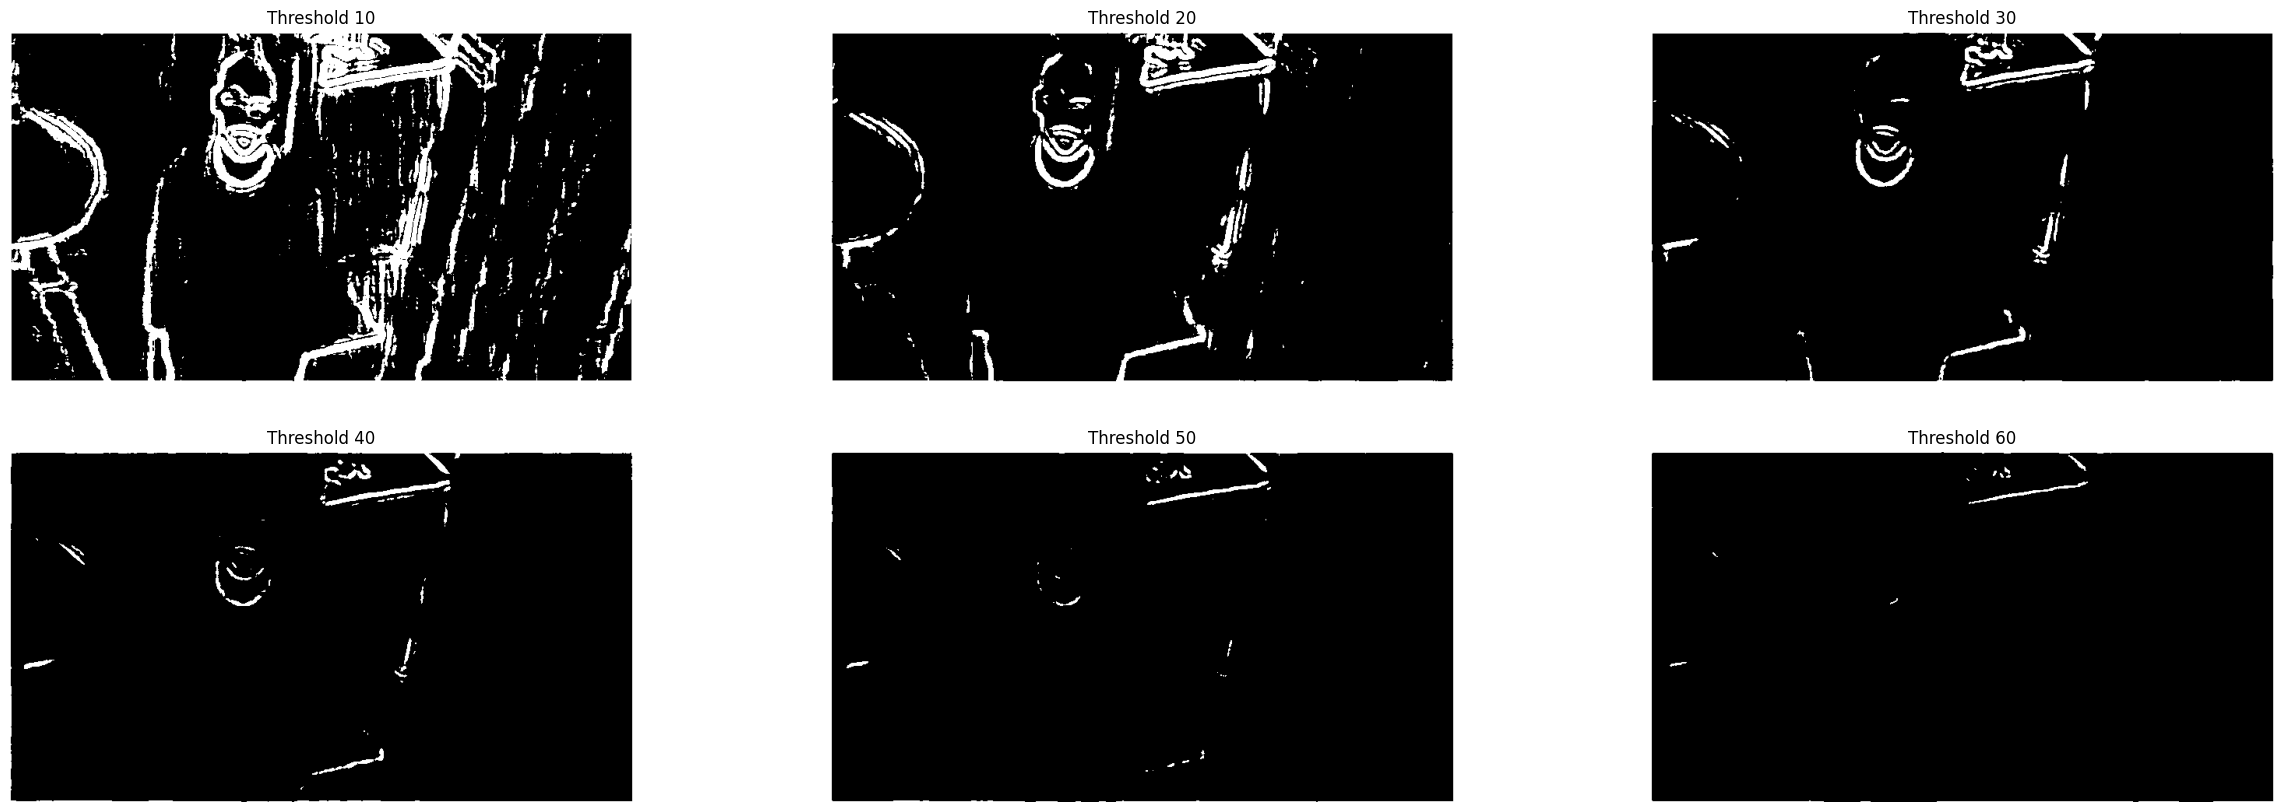

In [67]:
nilai_thresholding10 = 10 
tresh10 = np.where(prewitt_normal >= nilai_thresholding10, 255, 0).astype(np.uint8)

nilai_thresholding20 = 20 
tresh20 = np.where(prewitt_normal >= nilai_thresholding20, 255, 0).astype(np.uint8)

nilai_thresholding30 = 30 
tresh30 = np.where(prewitt_normal >= nilai_thresholding30, 255, 0).astype(np.uint8)

nilai_thresholding40 = 40
tresh40 = np.where(prewitt_normal >= nilai_thresholding40, 255, 0).astype(np.uint8)

nilai_thresholding50 = 50
tresh50 = np.where(prewitt_normal >= nilai_thresholding50, 255, 0).astype(np.uint8)

nilai_thresholding60 = 60
tresh60 = np.where(prewitt_normal >= nilai_thresholding60, 255, 0).astype(np.uint8)

plt.figure(figsize=(30, 10))

plt.subplot(2,3,1)
plt.title("Threshold 10")
plt.imshow(tresh10, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Threshold 20")
plt.imshow(tresh20, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Threshold 30")
plt.imshow(tresh30, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Threshold 40")
plt.imshow(tresh40, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Threshold 50")
plt.imshow(tresh50, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Threshold 60")
plt.imshow(tresh60, cmap='gray')
plt.axis('off')

plt.show()

Jelaskan pengaruh penggunaan threshold!
Jawaban:
Penggunaan threshold berpengaruh terhadap jumlah detail objek atau tepi yang ditampilkan pada citra hasil pengolahan. Jika nilai threshold rendah, maka lebih banyak piksel yang dianggap sebagai bagian objek sehingga detail dan noise masih banyak terlihat. Sebaliknya, jika nilai threshold tinggi, hanya piksel dengan intensitas besar yang dipertahankan sehingga citra terlihat lebih bersih tetapi beberapa detail penting dapat hilang. Oleh karena itu, pemilihan nilai threshold yang tepat sangat penting agar hasil segmentasi atau deteksi tepi menjadi lebih jelas dan sesuai kebutuhan.

Apa perbedaan mencolok dari threshold rendah dan tinggi?
Jawaban:
Perbedaan mencolok antara threshold rendah dan threshold tinggi terletak pada jumlah detail yang ditampilkan pada citra. Threshold rendah menghasilkan lebih banyak area putih karena banyak piksel yang lolos seleksi, sehingga detail objek dan noise masih terlihat cukup banyak. Sedangkan threshold tinggi menghasilkan area putih yang lebih sedikit karena hanya piksel dengan intensitas kuat yang dipertahankan, sehingga citra terlihat lebih bersih namun beberapa detail kecil atau tepi lemah dapat hilang.

Berapa nilai Threshold paling bagus untuk kasus ini? berikan alasannya!
Jawaban:
Nilai threshold yang paling bagus pada kasus ini adalah nilai yang mampu menampilkan tepi objek dengan jelas tanpa terlalu banyak noise maupun kehilangan detail penting. Berdasarkan hasil percobaan beberapa nilai threshold, biasanya nilai tengah seperti 30 atau 40 lebih optimal karena dapat menyeimbangkan antara jumlah detail tepi dan kebersihan citra. Threshold yang terlalu rendah masih menampilkan banyak noise, sedangkan threshold yang terlalu tinggi membuat beberapa bagian tepi objek hilang sehingga hasil deteksi menjadi kurang lengkap.


Kode di bawah ini digunakan untuk melakukan segmentasi objek dan penambahan efek visual pada citra. Program dimulai dengan membaca gambar lalu mengubahnya menjadi citra RGB dan grayscale, kemudian membuat mask berdasarkan rentang intensitas piksel dan area tertentu untuk memisahkan objek dari latar belakang. Setelah itu dilakukan proses perbaikan mask menggunakan pengecekan tetangga piksel, median filter untuk mengurangi noise, serta dilasi untuk memperbesar area objek. Selanjutnya, dilakukan deteksi tepi menggunakan operator Sobel untuk menghasilkan outline objek. Pada tahap akhir, area objek diberi efek perubahan warna agar lebih menonjol, sedangkan bagian outline diberi warna terang sehingga objek terlihat lebih jelas pada hasil akhir.

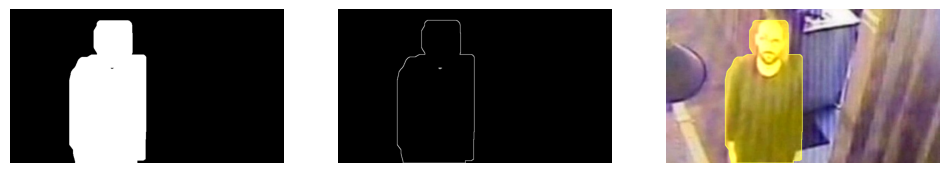

In [80]:
img = cv2.imread('backup.jpg')
backuprgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
backup = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def median_filter(img, size):
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    h, w = img.shape
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            result[i, j] = np.median(region)
    return result

def dilate(img, size):
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    h, w = img.shape
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            result[i, j] = np.max(region)
    return result

tinggi, lebar = backup.shape
mask = np.zeros((tinggi, lebar), dtype=np.uint8)

x1, y1 = 190, 50
x2, y2 = 380, 450

for i in range(tinggi):
    for j in range(lebar):
        if y1 <= i <= y2 and x1 <= j <= x2:
            if i < 150:
                if 220 <= j <= 340:
                    if 170 < backup[i, j] < 245:
                        mask[i, j] = 255
            else:
                if 45 < backup[i, j] < 110:
                    mask[i, j] = 255

mask_baru = np.zeros_like(mask)
for i in range(1, tinggi-1):
    for j in range(1, lebar-1):
        jumlah = 0
        for a in range(-1, 2):
            for b in range(-1, 2):
                if mask[i+a, j+b] == 255:
                    jumlah += 1
        if jumlah >= 5:
            mask_baru[i, j] = 255
mask = mask_baru

mask = median_filter(mask, 15)
mask = dilate(mask, 35)

for i in range(tinggi):
    for j in range(lebar):
        if mask[i, j] > 127:
            mask[i, j] = 255
        else:
            mask[i, j] = 0

outline = edge(mask, sobelX, sobelY)
hasil = backuprgb.copy()

for i in range(tinggi):
    for j in range(lebar):
        if mask[i, j] == 255:
            hasil[i, j, 0] = min(255, int(hasil[i, j, 0]) + 80)
            hasil[i, j, 1] = min(255, int(hasil[i, j, 1]) + 80)
            hasil[i, j, 2] = max(0, int(hasil[i, j, 2]) - 60)
        if outline[i, j] > 80:
            hasil[i, j, 0] = 255
            hasil[i, j, 1] = 255
            hasil[i, j, 2] = 80


plt.figure(figsize=(12,12))

plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(outline, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.axis('off')

plt.show()

Kode di bawah ini digunakan untuk membaca dan menampilkan citra dalam bentuk grayscale. Fungsi cv2.imread() digunakan untuk memuat gambar david.jpg, kemudian cv2.cvtColor() mengubah citra berwarna menjadi citra abu-abu menggunakan format COLOR_BGR2GRAY. Setelah itu, citra grayscale ditampilkan menggunakan matplotlib dengan colormap abu-abu (cmap='gray') dan sumbu gambar disembunyikan menggunakan axis('off').

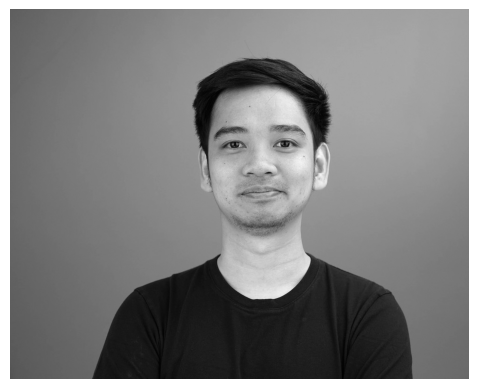

In [81]:
david = cv2.imread('david.jpg')
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)
plt.imshow(david_gray, cmap='gray')
plt.axis('off')
plt.show()

Kode di bawah ini digunakan untuk melakukan proses smoothing dan sharpening pada citra grayscale david_gray menggunakan fungsi konvolusi dan kernel yang telah dibuat sebelumnya. Proses smoothing bertujuan menghaluskan citra serta mengurangi noise, sedangkan sharpening digunakan untuk mempertajam detail dan tepi objek pada gambar. Setelah itu, kedua hasil digabungkan menjadi sm_plus_sh_david agar citra menjadi lebih bersih namun tetap tajam. Seluruh hasil kemudian ditampilkan menggunakan matplotlib untuk membandingkan efek smoothing, sharpening, dan kombinasi keduanya.

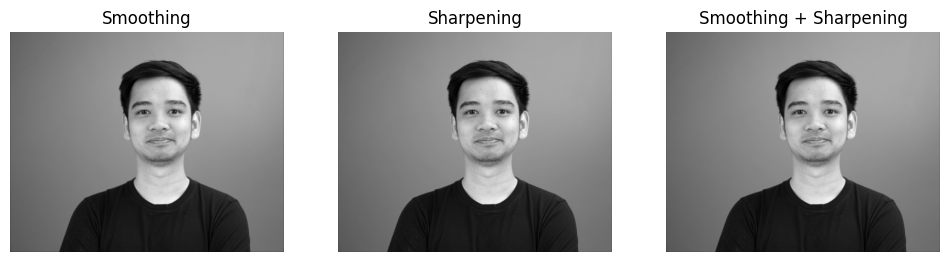

In [83]:
smooth_david = convolution (david_gray, kernelSmoothing)
sharp_david  = convolution (david_gray, kernelSharpening)
sm_plus_sh_david = smooth_david + sharp_david

plt.figure(figsize=(12,12))

plt.subplot(1,3,1)
plt.title("Smoothing")
plt.imshow(smooth_david, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sharpening")
plt.imshow(sharp_david, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Smoothing + Sharpening")
plt.imshow(sm_plus_sh_david, cmap='gray')
plt.axis('off')

plt.show()

Kode di bawah ini digunakan untuk melakukan deteksi tepi pada citra sm_plus_sh_david menggunakan operator Prewitt, Sobel, dan Roberts. Fungsi edge() melakukan konvolusi dengan kernel horizontal dan vertikal untuk mendeteksi perubahan intensitas piksel yang menunjukkan tepi objek pada citra. Setelah itu, hasil deteksi tepi dinormalisasi menggunakan fungsi normalisasi() agar nilai piksel berada pada rentang 0–255 sehingga tampilan citra lebih jelas. Seluruh hasil kemudian ditampilkan menggunakan matplotlib untuk membandingkan hasil deteksi tepi dari masing-masing operator.

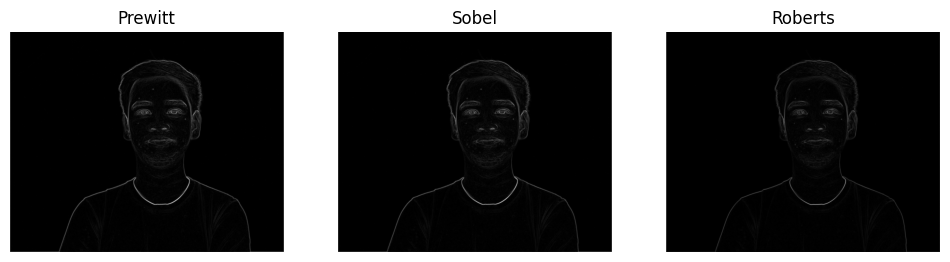

In [88]:
david_prewitt = edge(sm_plus_sh_david, prewittX, prewittY)
david_sobel   = edge(sm_plus_sh_david, sobelX, sobelY)
david_roberts = edge(sm_plus_sh_david, robertsX, robertsY)

david_prewitt_normal = normalisasi(david_prewitt)
david_sobel_normal = normalisasi(david_sobel)
david_robert_normal = normalisasi(david_roberts)

plt.figure(figsize=(12,12))

plt.subplot(1, 3, 1)
plt.imshow(david_prewitt_normal, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(david_sobel_normal, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(david_robert_normal, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.show()

Kode di bawah ini digunakan untuk menggabungkan hasil deteksi tepi dari operator Prewitt dan Sobel pada citra David. Kedua citra terlebih dahulu diubah menjadi tipe data float32 agar proses penjumlahan nilai piksel dapat dilakukan dengan aman tanpa kehilangan data. Setelah digabung, hasilnya dinormalisasi menggunakan fungsi normalisasi() agar rentang nilai piksel kembali berada pada 0–255 sehingga citra dapat ditampilkan dengan jelas. Hasil akhir kemudian ditampilkan menggunakan matplotlib dalam bentuk citra grayscale.

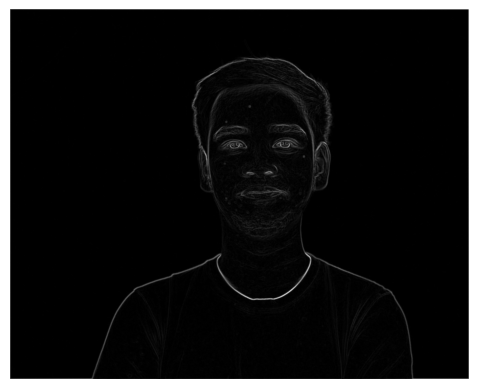

In [87]:
david_ps  = david_prewitt.astype(np.float32) + david_sobel.astype(np.float32)
david_ps_normal = normalisasi(david_ps)

plt.imshow(david_ps_normal, cmap='gray')
plt.axis('off')

plt.show()

Kode di bawah ini digunakan untuk melakukan segmentasi latar belakang dan deteksi tepi pada gambar david.jpg. Program dimulai dengan membaca citra lalu mengubah format warna dari BGR ke RGB secara manual, kemudian mengubahnya menjadi grayscale menggunakan rumus konversi intensitas. Setelah itu dilakukan deteksi tepi menggunakan operator Sobel untuk menampilkan garis tepi objek. Program juga memisahkan komponen warna merah, hijau, dan biru untuk membuat mask berdasarkan perbandingan nilai warna, sehingga area tertentu dapat dipisahkan dari latar belakang. Mask kemudian diperhalus menggunakan median filter, lalu area latar belakang diubah menjadi putih pada hasil akhir sehingga objek utama terlihat lebih jelas.

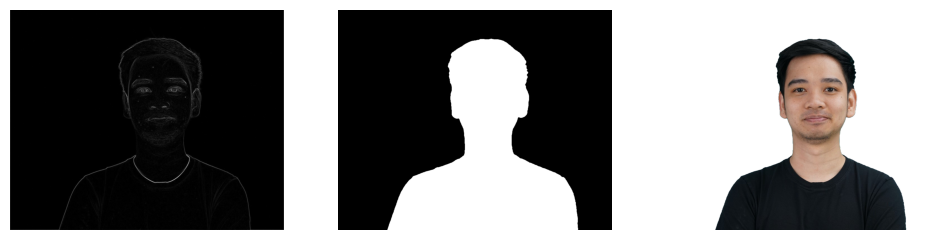

In [96]:
david_bgr = cv2.imread('david.jpg')
david_rgb = np.zeros_like(david_bgr)

for i in range(david_bgr.shape[0]):
    for j in range(david_bgr.shape[1]):
        david_rgb[i,j,0] = david_bgr[i,j,2]
        david_rgb[i,j,1] = david_bgr[i,j,1]
        david_rgb[i,j,2] = david_bgr[i,j,0]

gray_d = np.zeros((david_bgr.shape[0], david_bgr.shape[1]), dtype=np.uint8)
for i in range(david_bgr.shape[0]):
    for j in range(david_bgr.shape[1]):
        gray_d[i,j] = int(0.299 * david_rgb[i,j,0] + 0.587 * david_rgb[i,j,1] + 0.114 * david_rgb[i,j,2])

sobel_tepi = edge(gray_d, sobelX, sobelY)

r = np.zeros((david_bgr.shape[0], david_bgr.shape[1]), dtype=np.uint8)
g = np.zeros((david_bgr.shape[0], david_bgr.shape[1]), dtype=np.uint8)
b = np.zeros((david_bgr.shape[0], david_bgr.shape[1]), dtype=np.uint8)

for i in range(david_bgr.shape[0]):
    for j in range(david_bgr.shape[1]):
        b[i,j] = david_bgr[i,j,0] 
        g[i,j] = david_bgr[i,j,1]
        r[i,j] = david_bgr[i,j,2]

mask_david = np.zeros_like(gray_d)
for i in range(david_bgr.shape[0]):
    for j in range(david_bgr.shape[1]):
        if int(g[i,j]) > int(r[i,j]) + 30 and int(b[i,j]) > int(r[i,j]) + 30:
            mask_david[i,j] = 0
        else:
            mask_david[i,j] = 255

mask_david = filter(mask_david, 5, 'median')

result_david = david_rgb.copy()
for i in range(david_bgr.shape[0]):
    for j in range(david_bgr.shape[1]):
        if mask_david[i,j] == 0:
            result_david[i,j,0] = 255
            result_david[i,j,1] = 255
            result_david[i,j,2] = 255

plt.figure(figsize=(12,12))

plt.subplot(2,3,1)
plt.imshow(sobel_tepi, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(mask_david, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_david)
plt.axis('off')

plt.show()

Jelaskan Bagaimana proses perubahan dari citra awal hingga ke bagian penghilangan background.
Jawaban:
Proses perubahan dimulai dari citra awal berwarna yang dibaca menggunakan OpenCV, kemudian diubah dari format BGR ke RGB dan selanjutnya dikonversi menjadi grayscale untuk mempermudah proses analisis citra. Setelah itu dilakukan deteksi tepi menggunakan operator Sobel untuk menampilkan batas objek pada gambar. Selanjutnya, program memisahkan kanal warna merah, hijau, dan biru untuk membuat mask berdasarkan perbandingan intensitas warna tertentu sehingga objek dapat dibedakan dari background. Mask yang dihasilkan kemudian diperhalus menggunakan median filter agar noise berkurang dan area objek lebih rapi. Pada tahap akhir, area yang dianggap sebagai background diubah menjadi warna putih sehingga background pada citra berhasil dihilangkan dan objek utama terlihat lebih jelas.

Analisis  
Berdasarkan hasil yang telah dilakukan, perbaikan kualitas citra memiliki peran penting dalam meningkatkan kualitas visual gambar agar informasi pada citra menjadi lebih jelas dan mudah dianalisis. Proses seperti smoothing, filtering, dan sharpening digunakan untuk mengurangi noise, memperhalus citra, serta mempertajam detail objek sehingga hasil pengolahan menjadi lebih optimal. Selain itu, deteksi tepi berfungsi untuk mengenali batas atau kontur objek pada citra dengan menonjolkan perubahan intensitas piksel. Metode seperti Sobel, Prewitt, dan Roberts membantu dalam proses identifikasi bentuk, segmentasi objek, serta analisis pola pada gambar. Dengan adanya perbaikan kualitas citra dan deteksi tepi, proses pengolahan citra digital menjadi lebih efektif dalam menghasilkan informasi visual yang lebih akurat dan mudah dipahami.

Kesimpulan  
Berdasarkan praktikum yang telah dilakukan, dapat disimpulkan bahwa perbaikan kualitas citra dan deteksi tepi memiliki peran penting dalam pengolahan citra digital untuk meningkatkan kualitas visual serta mempermudah analisis objek pada gambar. Filter statistik seperti mean, median, dan modus mampu memberikan efek yang berbeda dalam mengurangi noise dan mempertahankan detail citra, sedangkan metode deteksi tepi seperti Sobel, Prewitt, dan Roberts efektif dalam menampilkan batas objek berdasarkan perubahan intensitas piksel. Hasil praktikum juga menunjukkan bahwa setiap metode memiliki karakteristik dan keunggulan masing-masing tergantung kebutuhan pengolahan citra. Selain itu, penggunaan threshold, normalisasi, serta kombinasi operator membantu menghasilkan citra yang lebih jelas dan informatif. Dengan demikian, tujuan praktikum untuk memahami perbaikan kualitas citra dan menerapkan algoritma deteksi tepi pada citra nyata telah berhasil dicapai.